In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime,timedelta
import matplotlib.dates as mdates
from oceanicospy.plots import *

In [2]:
path_case = '../data/model_runs/1D_xbeach/'
ini_date = datetime(2008, 11, 20, 11)

Once the case is run and the output NetCDF file is generated and placed in the `output` directory, the post-processing work can be done using libraries like `xarray` and `matplotlib` directly. 

In [3]:
ds_output = xr.open_dataset(f'{path_case}output/E1_profile1D_Nov2008.nc')

A quick view to the output dataset shows that it contains the expected variables and dimensions for profile and point outputs.

In [4]:
ds_output

<xarray.Dataset> Size: 3MB
Dimensions:      (ny: 1, nx: 651, globaltime: 107, pointtime: 107, points: 2)
Coordinates:
    globalx      (ny, nx) float64 5kB ...
    globaly      (ny, nx) float64 5kB ...
  * globaltime   (globaltime) float64 856B 0.0 3.6e+03 ... 3.78e+05 3.816e+05
  * pointtime    (pointtime) float64 856B 0.0 3.6e+03 ... 3.78e+05 3.816e+05
    pointx       (points) float64 16B ...
    pointy       (points) float64 16B ...
Dimensions without coordinates: ny, nx, points
Data variables: (12/15)
    _parameters  float64 8B ...
    zs           (globaltime, ny, nx) float64 557kB ...
    hh           (globaltime, ny, nx) float64 557kB ...
    zb0          (globaltime, ny, nx) float64 557kB ...
    H            (globaltime, ny, nx) float64 557kB ...
    u            (globaltime, ny, nx) float64 557kB ...
    ...           ...
    ypointindex  (points) int32 8B ...
    pointtypes   (points) int32 8B ...
    point_zs     (pointtime, points) float64 2kB ...
    point_H      (pointtime, points) float64 2kB ...
    point_urms   (pointtime, points) float64 2kB ...
    point_Sxx    (pointtime, points) float64 2kB ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  
    Build-Date:      Sat Nov 26 18:36:59 UTC 2022
    URL:

The profile and point outputs will have dimensions corresponding to time, x, and y. This structure allows for easy access and analysis of both spatial and temporal data from the XBeach simulation.

In [5]:
ds_profile = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim > 2]]
ds_point = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim == 2]]

### Profile output

The profile output contains the spatially distributed variables along the cross-shore profile. The variables are plotted along with the bed elevation (`zb0`), which can be plotted to visualize the bathymetric profile.

In [6]:
ds_point

<xarray.Dataset> Size: 8kB
Dimensions:     (pointtime: 107, points: 2)
Coordinates:
  * pointtime   (pointtime) float64 856B 0.0 3.6e+03 ... 3.78e+05 3.816e+05
    pointx      (points) float64 16B ...
    pointy      (points) float64 16B ...
Dimensions without coordinates: points
Data variables:
    point_zs    (pointtime, points) float64 2kB ...
    point_H     (pointtime, points) float64 2kB ...
    point_urms  (pointtime, points) float64 2kB ...
    point_Sxx   (pointtime, points) float64 2kB ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  
    Build-Date:      Sat Nov 26 18:36:59 UTC 2022
    URL:

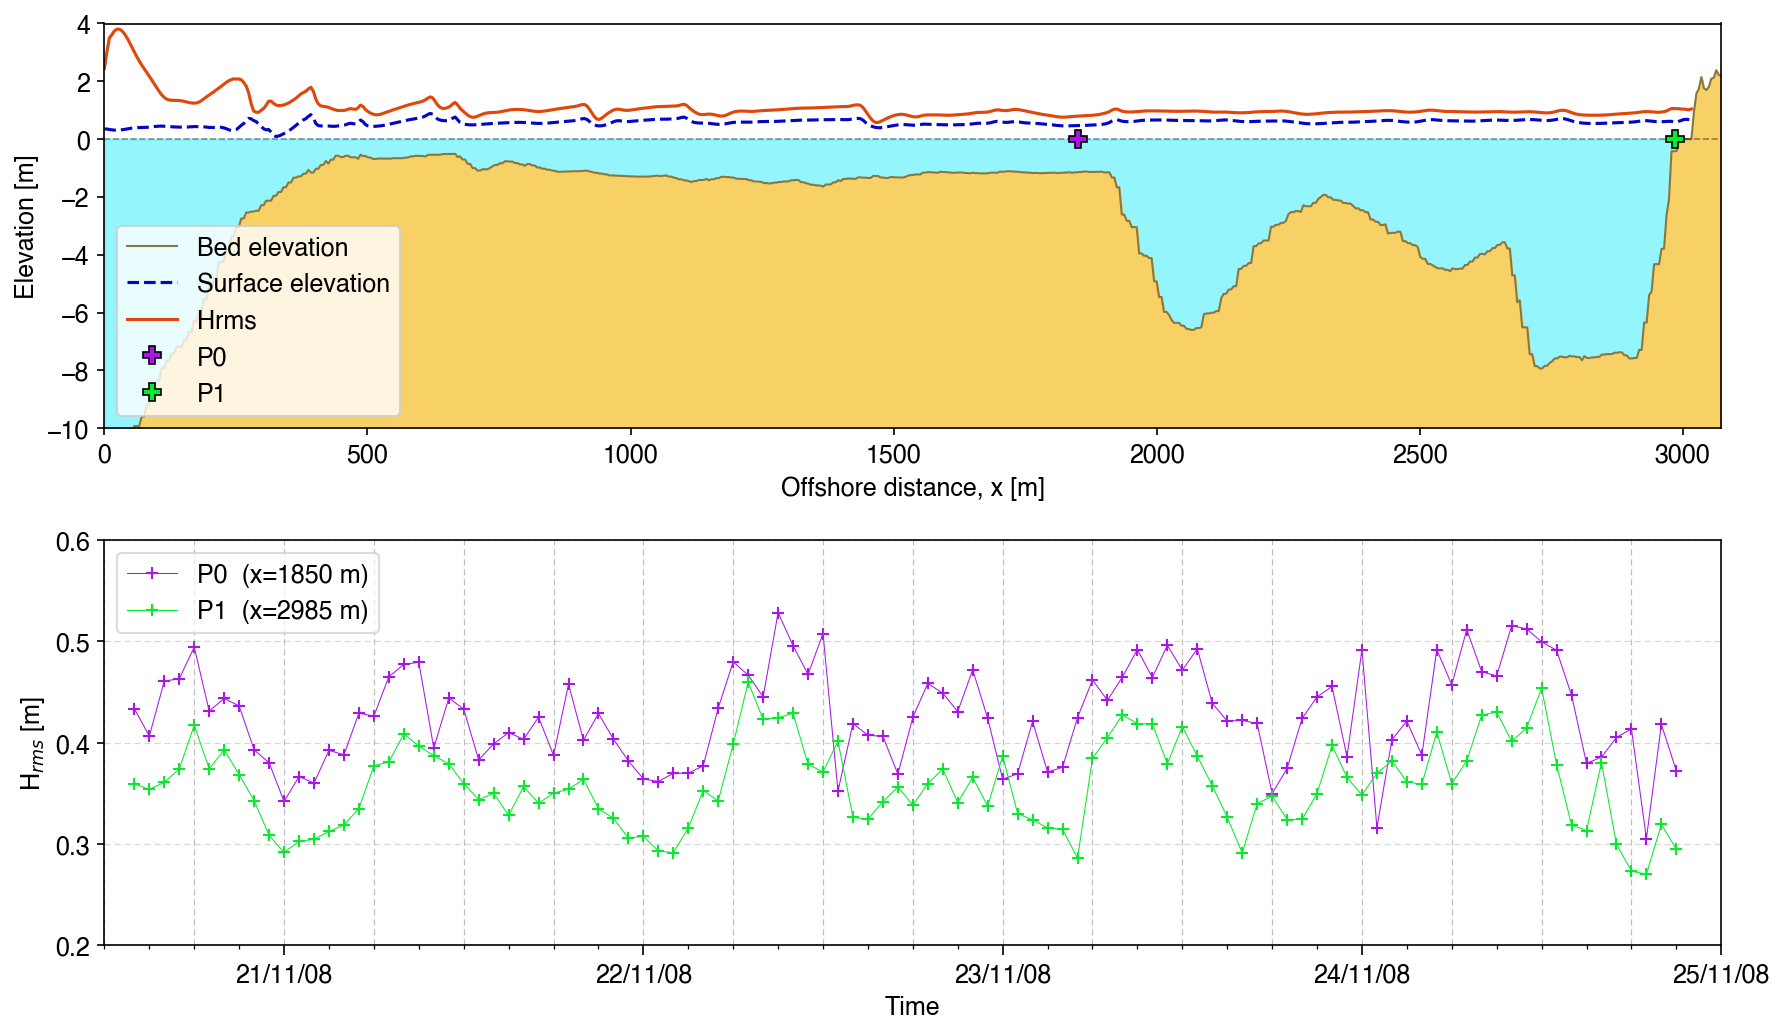

In [7]:
x     = ds_profile.globalx[0,:].values
x_pos = np.abs(x)

# Cross-shore transect
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(12, 7))
ax1.plot(x_pos, ds_profile.zb0.values[-1,0,:],  c="#8A7640",   lw=1, label='Bed elevation')
ax1.plot(x_pos, ds_profile.zs.values[-1,0,:],   c="#0505C4", lw=1.5, ls='--', label='Surface elevation')
ax1.plot(x_pos, ds_profile.hh.values[-1,0,:] + ds_profile.zb0.values[-1,0,:] + ds_profile.H.values[-1,0,:],
         c="#E0470A", lw=1.5, ls='-', label='Hrms')

color_points = ["#A817E7", "#08EA2E"]
for index in range(ds_point.pointx.values.shape[0]):
    ax1.plot(
        np.abs(ds_point.pointx.values[index]),
        0,
        marker='P',
        markersize=9,
        linestyle='None',
        zorder=5,
        markerfacecolor=color_points[index],
        markeredgecolor="#000000",
        markeredgewidth=0.8,
        label=f'P{index}'
    )
ax1.fill_between(x_pos, 0, np.min(ds_profile.zb0.values[-1,0,:]),
                 color="#69F2FC", alpha=0.7)
ax1.fill_between(x_pos, ds_profile.zb0.values[-1,0,:], np.min(ds_profile.zb0.values[-1,0,:]),
                 color="#F8D166")
ax1.axhline(0, c='black', ls='--', lw=0.8, alpha=0.4)

ax1.set_ylabel('Elevation [m]')
ax1.set_xlabel('Offshore distance, x [m]')
ax1.set_xlim(x_pos.min(), x_pos.max())
ax1.set_ylim(-10, 4)
ax1.tick_params(axis='y', which='minor', left=False)
ax1.legend(loc='lower left', framealpha=0.8)

# Hrms time series at output points
time = np.array([ini_date + timedelta(seconds=int(s)) for s in ds_point.pointtime.values])
H    = ds_point.point_H.values

warmup_idx = np.searchsorted(time, ini_date + timedelta(hours=3))
time_plot  = time[warmup_idx:]
H_plot     = H[warmup_idx:, :]

for index in range(H_plot.shape[1]):
    px = np.abs(ds_point.pointx.values[index])
    py = ds_point.pointy.values[index]
    ax2.plot(time_plot, H_plot[:, index],
             color=color_points[index], lw=0.5,
             marker='+', markersize=6, markevery=1,
             label=f'P{index}  (x={px:.0f} m)')

ax2.set_xlim(time_plot[0] - timedelta(minutes=120), time_plot[-1] + timedelta(minutes=180))
ax2.set_yticks(np.arange(0.2, 0.61, 0.1))

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
ax2.xaxis.set_minor_locator(mdates.HourLocator(interval=3))

for t in mdates.drange(
        time.min()+timedelta(minutes=60),
        time.max(),    
        pd.Timedelta(hours=6)
):
    ax2.axvline(t, color='gray', alpha=0.5, linestyle=(0, (5, 3)), lw=0.6)
ax2.grid(axis='y', which='major', alpha=0.5, linestyle=(0, (5, 3)), lw=0.6)

ax2.set_xlabel('Time')
ax2.set_ylabel('H$_{rms}$ [m]')
ax2.tick_params(axis='x', which='major', length=5)
ax2.legend(framealpha=0.7)

plt.tight_layout(h_pad=1.5)
plt.savefig('figure_illustrative_example.png', dpi=500, bbox_inches='tight', pad_inches=0.05)